# Final CLAMP models — LV–trait association (GLS) results

Inspection of `phenoplier shortcut gls` output for the three **final production
models**, one `CLAMPfull_bp` per dataset, run against the `phenomexcan_rapid_gwas`
cohort. The exact launcher is committed under `scripts/phenoplier/final_models/`.

> **The GLS step ran on the biomedical trait subset only.** Every run used
> `--trait-filter biomedical`, which **drops the 1,683 non-biomedical phenotypes**
> (occupational/job codes, medication codes, 24-hour diet-recall, household/admin
> and environmental-exposure fields) *before* computing — so results below cover
> the **2,366 of 4,049** biomedical traits, and the excluded traits are never
> tested. This also shrinks the Benjamini–Hochberg test count, so these numbers
> are not comparable to an unfiltered run (keep the filter fixed across a model
> set). See `phenoplier-cli` `docs/development/trait-filtering-standard.md`.

| Dataset | genes × LVs |
|---|---|
| ARCHS4 | 18,423 × 1,728 |
| GTEx | 21,613 × 578 |
| Recount2 | 6,000 × 724 |

Results live in the phenoplier workspace under
`projects/final_<ds>_CLAMPfull_bp/results/gls/phenoplier/`. Point `WS` below at
that workspace (defaults to the pico path; override with `CLAMP_PHENOPLIER_WS`).

In [1]:
%matplotlib inline
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WS = Path(os.environ.get("CLAMP_PHENOPLIER_WS", "/pividori_lab/phenoplier_workspace"))
DATASETS = ["archs4", "gtex", "recount2"]

def summary_path(ds):
    return (WS / "projects" / f"final_{ds}_CLAMPfull_bp"
            / "results" / "gls" / "phenoplier" / "gls-summary-phenomexcan.tsv.gz")

gls = {}
for ds in DATASETS:
    p = summary_path(ds)
    if p.exists():
        gls[ds] = pd.read_csv(p, sep="\t", low_memory=False)
        print(f"{ds:9s} {len(gls[ds]):>10,} rows  <-  {p}")
    else:
        print(f"{ds:9s} MISSING  ({p})")

archs4     4,088,448 rows  <-  /pividori_lab/phenoplier_workspace/projects/final_archs4_CLAMPfull_bp/results/gls/phenoplier/gls-summary-phenomexcan.tsv.gz


gtex       1,367,548 rows  <-  /pividori_lab/phenoplier_workspace/projects/final_gtex_CLAMPfull_bp/results/gls/phenoplier/gls-summary-phenomexcan.tsv.gz


recount2   1,712,984 rows  <-  /pividori_lab/phenoplier_workspace/projects/final_recount2_CLAMPfull_bp/results/gls/phenoplier/gls-summary-phenomexcan.tsv.gz


## Counts per model

`lv_degenerate` marks fits the phenoplier-cli#85 SE-collapse guard flagged; their
`fdr` is `NaN` and never counts as significant.

In [2]:
rows = []
for ds, d in gls.items():
    deg = d["lv_degenerate"].fillna(False).astype(bool) if "lv_degenerate" in d else pd.Series(False, index=d.index)
    rows.append({
        "dataset": ds,
        "phenotypes": d["phenotype"].nunique(),
        "LVs": d["lv"].nunique(),
        "assoc (rows)": len(d),
        "min pvalue": d["pvalue"].min(),
        "zero pvalues": int((d["pvalue"] == 0).sum()),
        "degenerate LVs": int(d.loc[deg, "lv"].nunique()),
        "sig FDR<0.05": int((d["fdr"] < 0.05).sum()),
        "NaN fdr": int(d["fdr"].isna().sum()),
    })
counts = pd.DataFrame(rows).set_index("dataset")
counts

,phenotypes,LVs,assoc (rows),min pvalue,zero pvalues,degenerate LVs,sig FDR<0.05,NaN fdr
dataset,,,,,,,,
archs4,2366,1728,4088448,3.531620e-93,0,0,6140,0
gtex,2366,578,1367548,3.714450e-43,0,0,2337,0
recount2,2366,724,1712984,1.452990e-48,0,0,2975,0


## P-value distributions

Under the null the p-values are ~uniform; a spike near 0 is real signal. A spike
of *exact* zeros would indicate the SE-collapse artifact (phenoplier-cli#85) — we
expect none here.

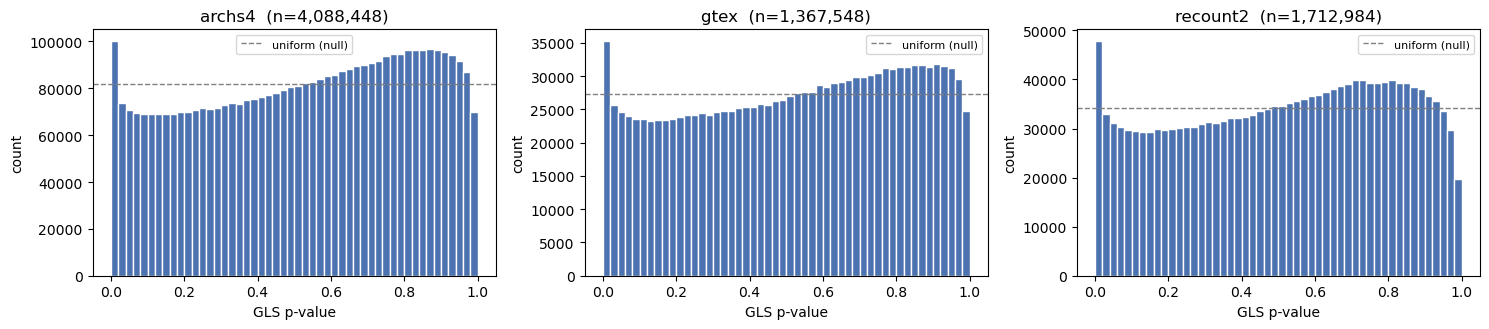

In [3]:
fig, axes = plt.subplots(1, len(gls), figsize=(5 * len(gls), 3.4), squeeze=False)
for ax, (ds, d) in zip(axes[0], gls.items()):
    ax.hist(d["pvalue"].dropna(), bins=50, color="#4C72B0", edgecolor="white")
    ax.axhline(len(d) / 50, color="grey", ls="--", lw=1, label="uniform (null)")
    ax.set_title(f"{ds}  (n={len(d):,})")
    ax.set_xlabel("GLS p-value")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Significant LV–trait associations (FDR < 0.05)

Note: `--trait-filter biomedical` shrinks the Benjamini–Hochberg test count, so
these are comparable across the three models here but **not** to unfiltered runs.

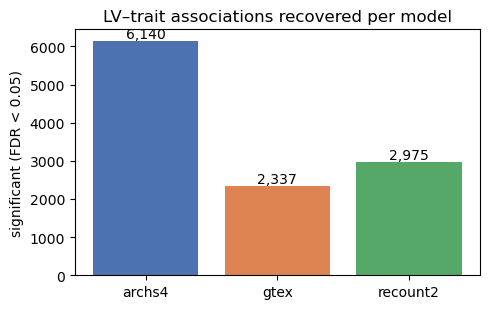

In [4]:
sig = counts["sig FDR<0.05"]
fig, ax = plt.subplots(figsize=(5, 3.2))
bars = ax.bar(sig.index, sig.values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.bar_label(bars, fmt="{:,.0f}")
ax.set_ylabel("significant (FDR < 0.05)")
ax.set_title("LV–trait associations recovered per model")
fig.tight_layout()
plt.show()

## Top associations per model

In [5]:
cols = [c for c in ["lv", "phenotype", "phenotype_desc", "pvalue", "fdr"] if c in next(iter(gls.values())).columns]
for ds, d in gls.items():
    print(f"=== {ds}: top 12 by FDR ===")
    display(d.sort_values("fdr")[cols].head(12).reset_index(drop=True))

=== archs4: top 12 by FDR ===


,lv,phenotype,phenotype_desc,pvalue,fdr
0,LV52,6151_4,Fractured bone site(s): Spine,3.531620e-93,1.443880e-86
1,LV267,E83,Diagnoses - main ICD10: E83 Disorders of miner...,4.454750e-61,9.106500e-55
2,LV52,5088_raw,Astigmatism angle (right),9.016050e-49,1.228720e-42
3,LV642,M13_FIBROBLASTIC,Fibroblastic disorders,7.634700e-47,7.803510e-41
4,LV642,M13_DUPUTRYEN,Palmar fascial fibromatosis [Dupuytren],1.124710e-46,9.196650e-41
5,LV642,M72,Diagnoses - main ICD10: M72 Fibroblastic disor...,3.206890e-46,2.185200e-40
6,LV52,H49,Diagnoses - main ICD10: H49 Paralytic strabismus,5.227940e-39,3.053450e-33
7,LV229,6149_1,Mouth/teeth dental problems: Mouth ulcers,3.613050e-38,1.846470e-32
8,LV736,2887,Number of cigarettes previously smoked daily,6.362860e-38,2.890470e-32
9,LV782,30190_raw,Monocyte percentage,6.571800e-37,2.686850e-31


=== gtex: top 12 by FDR ===


,lv,phenotype,phenotype_desc,pvalue,fdr
0,LV167,E83,Diagnoses - main ICD10: E83 Disorders of miner...,3.714450e-43,5.079690e-37
1,LV52,30240_raw,Reticulocyte percentage,1.476530e-36,1.009610e-30
2,LV52,30250_raw,Reticulocyte count,5.997550e-33,2.733980e-27
3,LV80,4120_raw,Heel broadband ultrasound attenuation (right),1.920070e-29,6.564480e-24
4,LV80,4101_raw,Heel broadband ultrasound attenuation (left),3.342430e-29,9.141860e-24
5,LV52,30280_raw,Immature reticulocyte fraction,1.729500e-28,3.539180e-23
6,LV52,30290_raw,High light scatter reticulocyte percentage,1.811580e-28,3.539180e-23
7,LV86,6149_1,Mouth/teeth dental problems: Mouth ulcers,5.254490e-28,8.982210e-23
8,LV565,E83,Diagnoses - main ICD10: E83 Disorders of miner...,2.691950e-25,4.090420e-20
9,LV482,30220_raw,Basophill percentage,1.443790e-24,1.974450e-19


=== recount2: top 12 by FDR ===


,lv,phenotype,phenotype_desc,pvalue,fdr
0,LV342,L72,Diagnoses - main ICD10: L72 Follicular cysts o...,1.452990e-48,2.488950e-42
1,LV42,30060_raw,Mean corpuscular haemoglobin concentration,4.462180e-33,3.821820e-27
2,LV342,XII_SKIN_SUBCUTAN,Diseases of the skin and subcutaneous tissue,1.204900e-32,6.879940e-27
3,LV147,20002_1473,"Non-cancer illness code, self-reported: high c...",1.043320e-27,4.467970e-22
4,LV208,20002_1473,"Non-cancer illness code, self-reported: high c...",2.818260e-25,9.655260e-20
5,LV248,C_BREAST_3,Malignant neoplasm of breast,1.092100e-22,3.117900e-17
6,LV556,6152_100,"Blood clot, DVT, bronchitis, emphysema, asthma...",3.792110e-22,9.279740e-17
7,LV446,6152_9,"Blood clot, DVT, bronchitis, emphysema, asthma...",1.044090e-21,2.235630e-16
8,LV594,20002_1473,"Non-cancer illness code, self-reported: high c...",1.359880e-21,2.588290e-16
9,LV136,C_BREAST_3,Malignant neoplasm of breast,2.437730e-21,4.175800e-16


## Traits recovered

How many distinct LV modules each trait is significantly associated with, per
model — the traits with the broadest module signal. Uses phenotype descriptions
so the same trait lines up across models even though the LV sets differ.

In [6]:
def sig_per_trait(d):
    s = d[d["fdr"] < 0.05]
    key = "phenotype_desc" if "phenotype_desc" in d.columns else "phenotype"
    return s.groupby(key)["lv"].nunique().rename("n_sig_LVs")

per = pd.concat({ds: sig_per_trait(d) for ds, d in gls.items()}, axis=1).fillna(0).astype(int)
per["total"] = per.sum(axis=1)
print(f"{len(per):,} traits significant in >=1 model")
per.sort_values("total", ascending=False).head(20)

1,638 traits significant in >=1 model


,archs4,gtex,recount2,total
phenotype_desc,,,,
Palmar fascial fibromatosis [Dupuytren],108,19,9,136
Mouth/teeth dental problems: Mouth ulcers,72,43,19,134
Diagnoses - main ICD10: M72 Fibroblastic disorders,101,18,9,128
Fibroblastic disorders,101,18,9,128
Illnesses of mother: Alzheimer's disease/dementia,63,18,33,114
Illnesses of father: Alzheimer's disease/dementia,59,15,33,107
Monocyte percentage,57,13,28,98
Hair/balding pattern: Pattern 2,83,2,10,95
"Non-cancer illness code, self-reported: high cholesterol",32,9,52,93


In [7]:
# Overlap of traits with >=1 significant module association across the models.
sig_traits = {}
for ds, d in gls.items():
    key = "phenotype_desc" if "phenotype_desc" in d.columns else "phenotype"
    sig_traits[ds] = set(d.loc[d["fdr"] < 0.05, key])
for ds, s in sig_traits.items():
    print(f"{ds:9s} {len(s):>5,} traits with a significant module")
if len(sig_traits) == 3:
    common = set.intersection(*sig_traits.values())
    print(f"\nshared by all three: {len(common):,}")

archs4    1,158 traits with a significant module
gtex        612 traits with a significant module
recount2    935 traits with a significant module

shared by all three: 304


## Reproducing

See `scripts/phenoplier/final_models/README.md`. In short (pico):

```bash
cd scripts/phenoplier/final_models
REG=$(sbatch --parsable 00_register_models.sbatch)
for ds in archs4 gtex recount2; do
  sbatch --dependency=afterok:$REG 01_run_final_gls.sbatch $ds
done
sbatch 02_build_stores.sbatch      # one HDF5 study store per model
```